In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

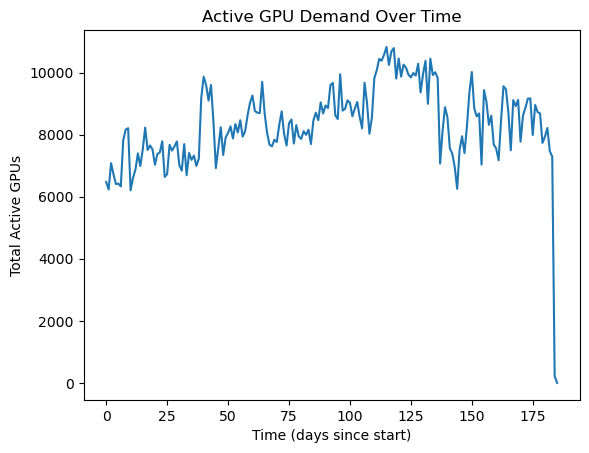

In [11]:
df = pd.read_csv("job_info_df.csv")

#convert all columns to numbers
df["submit_time"] = pd.to_numeric(df["submit_time"], errors="coerce")
df["duration"] = pd.to_numeric(df["duration"], errors="coerce")
df["gpu_request"] = pd.to_numeric(df["gpu_request"], errors="coerce")
df["worker_num"] = pd.to_numeric(df["worker_num"], errors="coerce")

#Keep only rows where creation_time and deletion_time exist since not each row has these paramaters
df = df.dropna()

# the size of each time window to 1 day
BIN_SIZE = 86400

#finds the earliest submit time in the whole dataset
t_start = int(df["submit_time"].min())
#compute the end time of every job (submit_time + duration)
t_end = int((df["submit_time"] + df["duration"]).max())
#build an array of time points from t_start to t_end with a step of 1 day
time_bins = np.arange(t_start, t_end + BIN_SIZE, BIN_SIZE)

gpu_demand = []

for t in time_bins:
    active_jobs = df[(df["submit_time"] <= t) & 
                     (df["submit_time"] + df["duration"] > t)]
    #filter the dataframe to only keep jobs that are running at time t
    total_gpu = (active_jobs["gpu_request"] * active_jobs["worker_num"]).sum()
    gpu_demand.append(total_gpu)

#convert seconds to days since start
time_bins_hours = (time_bins - t_start) / (3600*24)

plt.figure()
plt.plot(time_bins_hours, gpu_demand)
plt.xlabel("Time (days since start)")
plt.ylabel("Total Active GPUs")
plt.title("Active GPU Demand Over Time")
plt.show()